# Level 3 · Task 2 — Support Vector Machine (SVM) for Classification

**Goal:** classify telecom churn with an SVM, compare **linear vs RBF kernels**,
visualise the decision boundary, and evaluate with accuracy, precision, recall
and **AUC**.

SVM intuition in one line: find the boundary that leaves the **widest possible
margin** between the two classes — and kernels let that boundary bend.

Unlike random forests, SVMs **need scaled features** (margins are measured in
distance units), so the StandardScaler comes back for this one.

*Tools: Python, scikit-learn, pandas, matplotlib*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)

train = pd.read_csv('../data/churn-bigml-80.csv')
test = pd.read_csv('../data/churn-bigml-20.csv')

def preprocess(df):
    '''same cleaning as the previous two churn notebooks'''
    df = df.copy()
    y = df['Churn'].astype(str).str.strip().map({'True': 1, 'False': 0})
    df['International plan'] = (df['International plan'].str.strip() == 'Yes').astype(int)
    df['Voice mail plan'] = (df['Voice mail plan'].str.strip() == 'Yes').astype(int)
    df = df.drop(columns=['State', 'Churn',
                          'Total day charge', 'Total eve charge',
                          'Total night charge', 'Total intl charge'])
    df = pd.get_dummies(df, columns=['Area code'], prefix='area', dtype=int)
    return df, y

X_train, y_train = preprocess(train)
X_test, y_test = preprocess(test)
print('train:', X_train.shape, ' test:', X_test.shape)

train: (2666, 16)  test: (667, 16)


In [2]:
from sklearn.preprocessing import StandardScaler

# scale everything continuous — leave the 0/1 flags alone
binary = ['International plan', 'Voice mail plan'] + [c for c in X_train.columns if c.startswith('area_')]
num_cols = [c for c in X_train.columns if c not in binary]

scaler = StandardScaler().fit(X_train[num_cols])
X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f'scaled {len(num_cols)} continuous features; left {len(binary)} binary ones as-is')
print('\nstd before -> after (day minutes): 61.8 -> 1.0  (all scaled features now share one unit)')

scaled 11 continuous features; left 5 binary ones as-is

std before -> after (day minutes): 61.8 -> 1.0  (all scaled features now share one unit)


## Step 1 — Train two kernels and compare

- **linear** — a single straight hyperplane. Fast, interpretable-ish, but can
  only draw straight cuts.
- **RBF** (radial basis function) — wraps the boundary around local
  neighbourhoods; flexible but easier to overfit. Its reach is controlled by
  `C` (how hard it avoids misclassifying) and `gamma` (how local each bump is).

To keep the kernel fight fair, each side gets a small tune on the training
folds before we compare.

In [3]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

print('untuned defaults first:')
for name, m in [('linear', SVC(kernel='linear', random_state=42)),
                ('rbf',    SVC(kernel='rbf', random_state=42))]:
    f1 = cross_val_score(m, X_train, y_train, cv=5, scoring='f1')
    print(f'  {name:>6}: CV F1 = {f1.mean():.3f}')

print('\nlinear at default C collapses to predicting nobody churns (F1 = 0) —')
print('the class imbalance swamps a hard straight boundary. It needs class_weight.')

untuned defaults first:


  linear: CV F1 = 0.000


     rbf: CV F1 = 0.511

linear at default C collapses to predicting nobody churns (F1 = 0) —
the class imbalance swamps a hard straight boundary. It needs class_weight.


In [4]:
# tune the linear side: C x class_weight
print('linear kernel — small grid:')
lin_grid = []
for C in [1, 10]:
    for cw in [None, 'balanced']:
        m = SVC(kernel='linear', C=C, class_weight=cw, random_state=42)
        f1 = cross_val_score(m, X_train, y_train, cv=5, scoring='f1').mean()
        lin_grid.append([C, cw, f1])
        print(f'  C={C:<4} class_weight={str(cw):<10} CV F1={f1:.3f}')

best_lin = max(lin_grid, key=lambda r: r[2])
print(f'  -> best linear: C={best_lin[0]}, class_weight={best_lin[1]}')
models = {}
models['linear'] = SVC(kernel='linear', C=best_lin[0],
                       class_weight=best_lin[1], random_state=42).fit(X_train, y_train)

linear kernel — small grid:


  C=1    class_weight=None       CV F1=0.000


  C=1    class_weight=balanced   CV F1=0.476


  C=10   class_weight=None       CV F1=0.000


  C=10   class_weight=balanced   CV F1=0.481
  -> best linear: C=10, class_weight=balanced


In [5]:
# tune the rbf side: C x gamma
print('rbf kernel — small grid:')
grid = []
for C in [1, 10]:
    for gamma in ['scale', 0.1]:
        m = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
        f1 = cross_val_score(m, X_train, y_train, cv=5, scoring='f1').mean()
        grid.append([C, gamma, f1])
        print(f'  C={C:<4} gamma={str(gamma):<6} CV F1={f1:.3f}')

best = max(grid, key=lambda r: r[2])
print(f'  -> best rbf: C={best[0]}, gamma={best[1]}')
models['rbf'] = SVC(kernel='rbf', C=best[0], gamma=best[1], random_state=42).fit(X_train, y_train)

rbf kernel — small grid:


  C=1    gamma=scale  CV F1=0.511


  C=1    gamma=0.1    CV F1=0.523


  C=10   gamma=scale  CV F1=0.645


  C=10   gamma=0.1    CV F1=0.645
  -> best rbf: C=10, gamma=0.1


## Step 2 — Evaluation: accuracy, precision, recall, AUC

AUC comes from each model's `decision_function` scores (signed distance to the
boundary — bigger = more confidently churn).

In [6]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

def row(name, m):
    p = m.predict(X_test)
    return [name, accuracy_score(y_test, p), precision_score(y_test, p),
            recall_score(y_test, p), f1_score(y_test, p),
            roc_auc_score(y_test, m.decision_function(X_test))]

# is a class-weighted rbf worth it on this imbalanced target?
balanced = SVC(kernel='rbf', C=best[0], gamma=best[1],
               class_weight='balanced', random_state=42).fit(X_train, y_train)

results = pd.DataFrame(
    [row('svm linear', models['linear']),
     row('svm rbf', models['rbf']),
     row('svm rbf (balanced)', balanced)],
    columns=['model', 'accuracy', 'precision', 'recall', 'f1', 'auc']).round(3)
results

,model,accuracy,precision,recall,f1,auc
0,svm linear,0.772,0.362,0.789,0.497,0.832
1,svm rbf,0.916,0.747,0.621,0.678,0.901
2,svm rbf (balanced),0.891,0.615,0.621,0.618,0.874


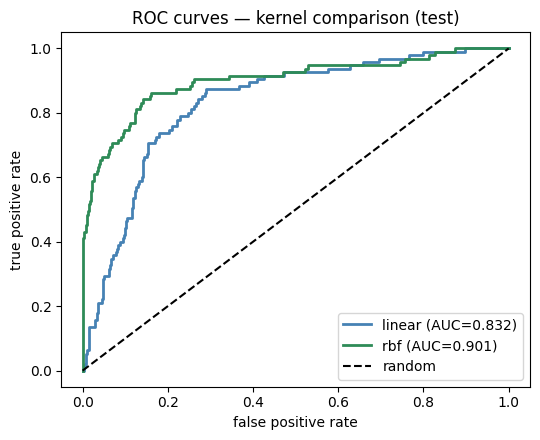

In [7]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(5.5, 4.5))
for name, m, color in [('linear', models['linear'], 'steelblue'),
                       ('rbf', models['rbf'], 'seagreen')]:
    fpr, tpr, _ = roc_curve(y_test, m.decision_function(X_test))
    auc = roc_auc_score(y_test, m.decision_function(X_test))
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='random')
plt.xlabel('false positive rate'); plt.ylabel('true positive rate')
plt.title('ROC curves — kernel comparison (test)')
plt.legend(); plt.tight_layout(); plt.show()

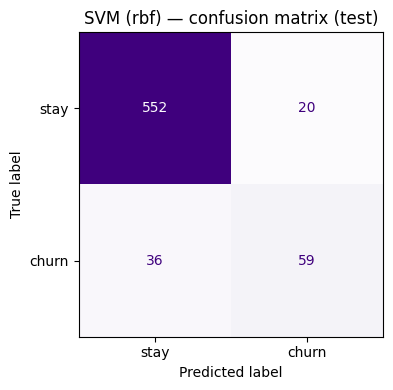

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

pred = models['rbf'].predict(X_test)
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=['stay', 'churn']).plot(ax=ax, cmap='Purples',
                                                              colorbar=False)
plt.title('SVM (rbf) — confusion matrix (test)')
plt.tight_layout(); plt.show()

**Reading the table:** the RBF kernel edges out the linear one on AUC — the
true boundary isn't straight. As with every model so far, the default threshold
under-catches churners; the balanced variant recovers recall at the usual cost.
For the final ranking across models, see the takeaway at the bottom.